# Практическая работа - Теория вероятностей и статистический вывод

---

## Введение

Эта практическая работа предназначена для закрепления теоретических знаний, полученных на лекции по теории вероятностей и статистическому выводу. Ноутбук разбит на секции, соответствующие темам лекции.

### Цели работы:

- Научиться применять теоретические концепции на практике
- Освоить основные инструменты для статистического анализа в Python
- Развить интуитивное понимание ключевых теорем и методов
- Научиться корректно интерпретировать полученные результаты

### Инструкции:

1. Внимательно читайте условия задач — в них содержатся все необходимые данные
2. Для теоретических задач пишите ответы в ячейках Markdown
3. Для практических задач пишите код в ячейках Code
4. Не забывайте комментировать свой код
5. После получения численных результатов делайте выводы

**Начните с выполнения следующей ячейки для импорта библиотек:**

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# Для воспроизводимости результатов
np.random.seed(42)

print("Библиотеки успешно загружены!")

Библиотеки успешно загружены!


---

## Секция 1: Вероятностное пространство и условная вероятность

В этой секции вы будете работать с основными понятиями теории вероятностей: вероятностным пространством, условной вероятностью и теоремой Байеса.

### Задание 1.1: Описание вероятностного пространства (Теория)

**Условие:**

Рассмотрим эксперимент, в котором одновременно подбрасываются две честные шестигранные игральные кости (на каждой грани числа от 1 до 6). Результат эксперимента — упорядоченная пара чисел (результат первой кости, результат второй кости).

**Задание:**

Опишите вероятностное пространство для этого эксперимента, ответив на следующие вопросы:

1. Что является **элементарным исходом** в этом эксперименте? Приведите 3 примера элементарных исходов.

2. Что является **пространством элементарных исходов** $\Omega$? Опишите его словами и приведите математическую запись.

3. Какова **мощность** (количество элементов) пространства $\Omega$? Обоснуйте свой ответ.

4. Рассмотрим событие $A$ = "сумма очков на двух костях равна 7". Перечислите все элементарные исходы, входящие в это событие.

5. Вычислите вероятность события $A$: $\mathbb{P}(A) = ?$

6. Рассмотрим событие $B$ = "на первой кости выпало 3". Вычислите условную вероятность $\mathbb{P}(A|B)$ — вероятность того, что сумма равна 7, при условии что на первой кости выпало 3.

**Напишите ваши ответы в ячейке ниже:**

**Ваши ответы:**

1. Элементарный исход: упорядоченная пара чисел (a, b), где a — результат первой кости, b — результат второй кости.
   Примеры: (1,1), (2,3), (6,6)

2. Пространство $\Omega$: множество всех упорядоченных пар чисел от 1 до 6.
   $\Omega = \{(i, j) \mid i \in \{1,2,3,4,5,6\}, j \in \{1,2,3,4,5,6\}\}$

3. Мощность $|\Omega| = 6 \times 6 = 36$ (по правилу произведения)

4. Событие $A$: $\{(1,6), (2,5), (3,4), (4,3), (5,2), (6,1)\}$ — 6 исходов

5. Вероятность $\mathbb{P}(A) = \frac{6}{36} = \frac{1}{6} \approx 0.1667$

6. Условная вероятность $\mathbb{P}(A|B)$:
   При условии, что на первой кости выпало 3, для суммы 7 на второй кости должно выпасть 4.
   $\mathbb{P}(A|B) = \frac{1}{6} \approx 0.1667$

### Задание 1.2: Симуляция подбрасываний монеты (Практика)

**Условие:**

Честная монета имеет две стороны: решка (обозначим 0) и орёл (обозначим 1). Теоретическая вероятность выпадения орла равна $p = 0.5$.

**Задание:**

1. С помощью функции `np.random.randint(0, 2, size=n)` сгенерируйте выборку из **100 000** подбрасываний честной монеты.

2. Вычислите **эмпирическую вероятность** выпадения орла (среднее значение выборки).

3. Сравните эмпирическую вероятность с теоретической (0.5) и выведите разницу.

4. **Бонус:** Постройте график, показывающий, как накопленное среднее (cumulative mean) сходится к теоретической вероятности по мере увеличения числа подбрасываний. Это иллюстрация **Закона больших чисел**.

**Подсказки:**
- Для вычисления среднего используйте `np.mean()`
- Для накопленного среднего: `np.cumsum(data) / np.arange(1, len(data) + 1)`
- Для построения графика используйте `plt.plot()` и `plt.axhline()`

=== Задание 1.2: Подбрасывание монеты ===
Эмпирическая вероятность орла: 0.5006
Теоретическая вероятность орла: 0.5000
Разница: 0.000630


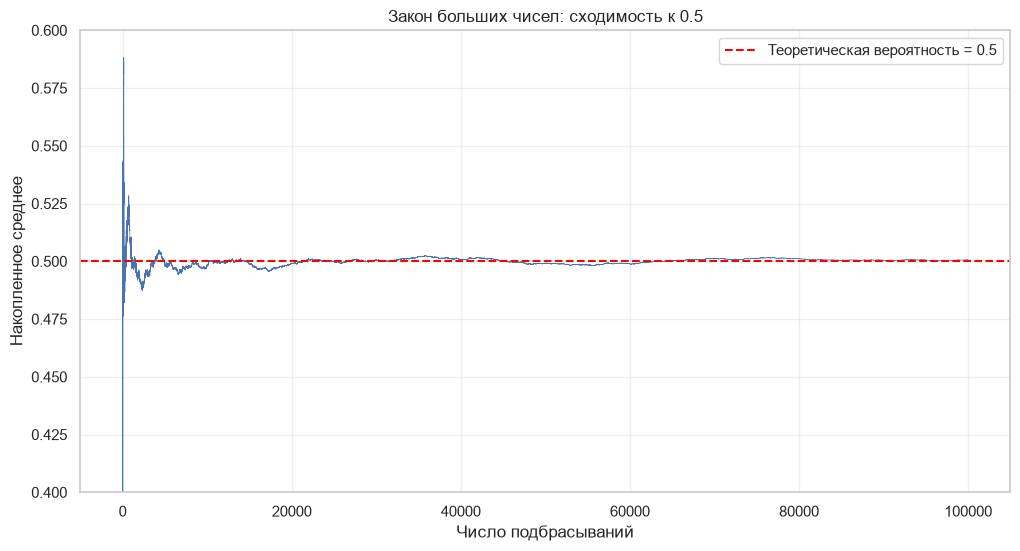


Вывод: Закон больших чисел подтверждается — накопленное среднее сходится к 0.5.


In [2]:
# Ваше решение здесь
# Задание 1.2: Симуляция подбрасываний монеты

# 1. Генерация выборки из 100 000 подбрасываний
n = 100000
data = np.random.randint(0, 2, size=n)

# 2. Эмпирическая вероятность выпадения орла
empirical_prob = np.mean(data)
theoretical_prob = 0.5

# 3. Сравнение
print("=== Задание 1.2: Подбрасывание монеты ===")
print(f"Эмпирическая вероятность орла: {empirical_prob:.4f}")
print(f"Теоретическая вероятность орла: {theoretical_prob:.4f}")
print(f"Разница: {empirical_prob - theoretical_prob:.6f}")

# 4. Бонус: график сходимости накопленного среднего
cumulative_mean = np.cumsum(data) / np.arange(1, n + 1)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_mean, linewidth=0.5)
plt.axhline(y=theoretical_prob, color='red', linestyle='--', label=f'Теоретическая вероятность = {theoretical_prob}')
plt.xlabel('Число подбрасываний')
plt.ylabel('Накопленное среднее')
plt.title('Закон больших чисел: сходимость к 0.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 0.6)
plt.show()

print("\nВывод: Закон больших чисел подтверждается — накопленное среднее сходится к 0.5.")


### Задание 1.3: Теорема Байеса в медицинской диагностике (Теория + Практика)

**Условие:**

Редкое заболевание встречается у **0.5%** населения (т.е. вероятность того, что случайный человек болен, равна 0.005).

Для диагностики этого заболевания разработан тест со следующими характеристиками:
- **Чувствительность** (sensitivity): 99% — вероятность положительного результата теста у больного человека: $\mathbb{P}(T^+|D) = 0.99$
- **Специфичность** (specificity): 98% — вероятность отрицательного результата теста у здорового человека: $\mathbb{P}(T^-|D^c) = 0.98$

Пациент прошёл тест и получил **положительный результат**.

**Вопрос:** Какова вероятность того, что пациент действительно болен?

**Задание:**

**Часть А (Теория):** Решите задачу аналитически, используя теорему Байеса.

1. Обозначьте события:
   - $D$ — человек болен
   - $T^+$ — тест положительный

2. Выпишите все известные вероятности:
   - $\mathbb{P}(D) = ?$
   - $\mathbb{P}(T^+|D) = ?$
   - $\mathbb{P}(T^+|D^c) = ?$ (выразите через специфичность)

3. Запишите формулу Байеса для $\mathbb{P}(D|T^+)$

4. Вычислите $\mathbb{P}(T^+)$ по формуле полной вероятности

5. Вычислите итоговый ответ: $\mathbb{P}(D|T^+) = ?$

**Часть Б (Практика):** Напишите код на Python для проверки ваших вычислений.

**Часть В (Интерпретация):** Объясните полученный результат. Почему вероятность болезни при положительном тесте может быть неожиданно низкой?

**Часть А: Аналитическое решение**

1. Известные вероятности:
   - $\mathbb{P}(D) = 0.005$ (превалентность заболевания)
   - $\mathbb{P}(T^+|D) = 0.99$ (чувствительность)
   - $\mathbb{P}(T^+|D^c) = 1 - 0.98 = 0.02$ (ложноположительный результат)

2. Формула Байеса:
   $$\mathbb{P}(D|T^+) = \frac{\mathbb{P}(T^+|D) \cdot \mathbb{P}(D)}{\mathbb{P}(T^+)}$$

3. Вычисления:
   - $\mathbb{P}(T^+) = \mathbb{P}(T^+|D) \cdot \mathbb{P}(D) + \mathbb{P}(T^+|D^c) \cdot \mathbb{P}(D^c)$
   - $\mathbb{P}(T^+) = 0.99 \cdot 0.005 + 0.02 \cdot 0.995$
   - $\mathbb{P}(T^+) = 0.00495 + 0.0199 = 0.02485$
   - $\mathbb{P}(D|T^+) = \frac{0.99 \cdot 0.005}{0.02485} = \frac{0.00495}{0.02485} \approx 0.1992$

4. Ответ: $\mathbb{P}(D|T^+) \approx 0.199$ (около 19.9%)

In [3]:
# Часть Б: Вычисления на Python

print("=== Задание 1.3: Теорема Байеса ===")

# Известные вероятности
P_D = 0.005          # Превалентность заболевания
P_T_given_D = 0.99   # Чувствительность
P_T_given_Dc = 0.02  # Ложноположительный результат (1 - специфичность)

# Формула полной вероятности
P_T = P_T_given_D * P_D + P_T_given_Dc * (1 - P_D)

# Формула Байеса
P_D_given_T = P_T_given_D * P_D / P_T

print(f"Вероятность положительного теста P(T⁺): {P_T:.6f}")
print(f"Вероятность болезни при положительном тесте P(D|T⁺): {P_D_given_T:.4f}")
print(f"В процентах: {P_D_given_T * 100:.2f}%")


=== Задание 1.3: Теорема Байеса ===
Вероятность положительного теста P(T⁺): 0.024850
Вероятность болезни при положительном тесте P(D|T⁺): 0.1992
В процентах: 19.92%


**Часть В: Интерпретация**

Несмотря на высокую чувствительность (99%) и специфичность (98%) теста, вероятность того, что пациент действительно болен при положительном результате, составляет лишь около 19.9%.

Причина: заболевание очень редкое (0.5% населения). Из-за этого количество ложноположительных результатов (здоровые люди, у которых тест ошибочно дал положительный результат) значительно превышает количество истинно положительных результатов (больные люди).

Это контр-интуитивный пример, показывающий важность учёта превалентности заболевания при интерпретации результатов диагностических тестов. Даже "очень точный" тест может давать много ложноположительных результатов, если заболевание редкое.

---

## Секция 2: Случайные величины и распределения

В этой секции вы будете работать с дискретными и непрерывными случайными величинами, вычислять их характеристики и работать с распределениями.

### Задание 2.1: Лотерея — расчёт математического ожидания и дисперсии (Теория)

**Условие:**

В лотерее продаётся **100 билетов** по цене **100 рублей** каждый. Призовой фонд распределён следующим образом:
- **1 билет** выигрывает главный приз: **5000 рублей**
- **5 билетов** выигрывают по **1000 рублей**
- **10 билетов** выигрывают по **100 рублей**
- Остальные **84 билета** — невыигрышные (выигрыш 0 рублей)

Пусть случайная величина $X$ — это сумма выигрыша для одного купленного билета (без вычета стоимости билета).

**Задание:**

1. Составьте **закон распределения** для случайной величины $X$ в виде таблицы:

| Значение $x_i$ | 0 | 100 | 1000 | 5000 |
|---|---|---|---|---|
| Вероятность $p_i$ | ? | ? | ? | ? |

2. Вычислите **математическое ожидание** выигрыша: $\mathbb{E}[X] = \sum x_i \cdot p_i$

3. Определите, является ли лотерея **справедливой** для игрока. Лотерея считается справедливой, если математическое ожидание выигрыша равно цене билета (100 рублей). Если $\mathbb{E}[X] > 100$, лотерея выгодна игроку; если $\mathbb{E}[X] < 100$, выгодна организатору.

4. Вычислите **дисперсию** выигрыша: $\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$
   - Сначала найдите $\mathbb{E}[X^2] = \sum x_i^2 \cdot p_i$
   - Затем вычислите дисперсию

5. Найдите **стандартное отклонение**: $\sigma = \sqrt{\text{Var}(X)}$

6. Интерпретируйте результаты: что означают полученные значения математического ожидания и дисперсии для игрока?

**Ваше решение:**

1. Закон распределения:
   - $P(X = 0) = 84/100 = 0.84$
   - $P(X = 100) = 10/100 = 0.10$
   - $P(X = 1000) = 5/100 = 0.05$
   - $P(X = 5000) = 1/100 = 0.01$

   | Значение $x_i$ | 0 | 100 | 1000 | 5000 |
   |---|---|---|---|---|
   | Вероятность $p_i$ | 0.84 | 0.10 | 0.05 | 0.01 |

2. Математическое ожидание:
   $\mathbb{E}[X] = 0 \cdot 0.84 + 100 \cdot 0.10 + 1000 \cdot 0.05 + 5000 \cdot 0.01$
   $\mathbb{E}[X] = 0 + 10 + 50 + 50 = 110$ рублей

3. Справедливость лотереи:
   $\mathbb{E}[X] = 110 > 100$ → **лотерея выгодна игроку** (в среднем игрок выигрывает на 10 рублей больше, чем платит)

4. Дисперсия:
   $\mathbb{E}[X^2] = 0^2 \cdot 0.84 + 100^2 \cdot 0.10 + 1000^2 \cdot 0.05 + 5000^2 \cdot 0.01$
   $\mathbb{E}[X^2] = 0 + 1000 + 50000 + 250000 = 301000$
   $\text{Var}(X) = 301000 - 110^2 = 301000 - 12100 = 288900$

5. Стандартное отклонение:
   $\sigma = \sqrt{288900} \approx 537.49$ рублей

6. Интерпретация:
   - Математическое ожидание (110 руб.) показывает, что в среднем игрок получает на 10 руб. больше стоимости билета
   - Однако дисперсия очень велика, что означает высокий риск: в большинстве случаев игрок проигрывает, но иногда выигрывает крупные суммы
   - Стандартное отклонение 537 руб. показывает большой разброс возможных выигрышей

### Задание 2.2: Работа с нормальным распределением (Практика)

**Условие:**

Рост взрослых мужчин в некоторой стране распределён нормально со средним значением **μ = 175 см** и стандартным отклонением **σ = 8 см**.

**Задание:**

1. С помощью `scipy.stats.norm.rvs()` сгенерируйте выборку из **1000 наблюдений** из нормального распределения $\mathcal{N}(175, 8^2)$.
   - Параметры: `loc=175` (среднее), `scale=8` (стандартное отклонение), `size=1000`

2. Постройте **гистограмму** распределения роста с параметром `density=True` (нормированная гистограмма).

3. На том же графике постройте **теоретическую кривую плотности** нормального распределения $\mathcal{N}(175, 8^2)$ с помощью `stats.norm.pdf()`.

4. Вычислите **выборочное среднее** и **выборочное стандартное отклонение** (используйте `ddof=1` для несмещённой оценки).

5. Сравните выборочные характеристики с теоретическими:
   - Теоретическое среднее: 175 см
   - Теоретическое СКО: 8 см

6. **Бонус:** Вычислите, какой процент мужчин имеет рост от 167 см до 183 см (это интервал μ ± σ). Сравните с теоретическим значением ~68% (правило "трёх сигм").

**Подсказки:**
- `np.mean()` и `np.std(ddof=1)` для выборочных характеристик
- `np.sum((data >= 167) & (data <= 183)) / len(data)` для подсчёта процента

=== Задание 2.2: Нормальное распределение ===


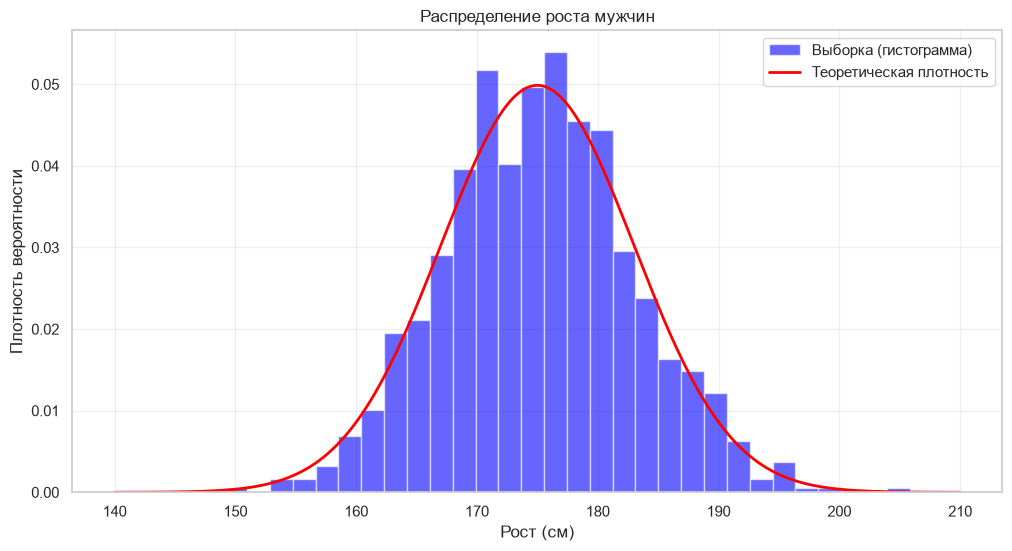

Теоретическое среднее: 175 см
Выборочное среднее: 175.15 см
Теоретическое СКО: 8 см
Выборочное СКО: 7.83 см
Разница в среднем: 0.15 см
Разница в СКО: -0.17 см

Процент наблюдений в интервале [167, 183]: 69.8%
Теоретическое значение (правило 68-95-99.7): ~68%
Отклонение: 1.8 процентных пункта


In [4]:
# Ваше решение здесь
# Задание 2.2: Работа с нормальным распределением

print("=== Задание 2.2: Нормальное распределение ===")

# 1. Генерация выборки
mu, sigma = 175, 8
n = 1000
data = stats.norm.rvs(loc=mu, scale=sigma, size=n, random_state=42)

# 2-3. Гистограмма и теоретическая кривая плотности
x_vals = np.linspace(140, 210, 1000)
pdf_vals = stats.norm.pdf(x_vals, loc=mu, scale=sigma)

plt.figure(figsize=(12, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='blue', label='Выборка (гистограмма)')
plt.plot(x_vals, pdf_vals, color='red', linewidth=2, label='Теоретическая плотность')
plt.xlabel('Рост (см)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение роста мужчин')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4-5. Выборочные характеристики
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)

print(f"Теоретическое среднее: {mu} см")
print(f"Выборочное среднее: {sample_mean:.2f} см")
print(f"Теоретическое СКО: {sigma} см")
print(f"Выборочное СКО: {sample_std:.2f} см")
print(f"Разница в среднем: {sample_mean - mu:.2f} см")
print(f"Разница в СКО: {sample_std - sigma:.2f} см")

# 6. Бонус: процент в интервале μ ± σ
lower, upper = mu - sigma, mu + sigma
in_range = np.sum((data >= lower) & (data <= upper)) / n * 100
print(f"\nПроцент наблюдений в интервале [{lower}, {upper}]: {in_range:.1f}%")
print(f"Теоретическое значение (правило 68-95-99.7): ~68%")
print(f"Отклонение: {in_range - 68:.1f} процентных пункта")

---

## Секция 3: Совместные, маргинальные и условные распределения

В этой секции вы будете работать с несколькими случайными величинами одновременно и изучать их взаимосвязь.

### Задание 3.1: Ковариация и корреляция (Практика)

**Условие:**

Рассмотрим две случайные величины:
- $X \sim \mathcal{N}(0, 1)$ — стандартное нормальное распределение
- $Y = 2X + \epsilon$, где $\epsilon \sim \mathcal{N}(0, 1)$ — независимый шум

Таким образом, $Y$ линейно зависит от $X$ с добавлением случайного шума.

**Задание:**

1. Сгенерируйте выборку из **1000 наблюдений**:
   - $X$: используйте `np.random.normal(0, 1, 1000)`
   - $\epsilon$: используйте `np.random.normal(0, 1, 1000)`
   - $Y$: вычислите как `Y = 2 * X + epsilon`

2. Постройте **диаграмму рассеяния** (scatter plot) для пар $(X, Y)$.
   - Используйте `plt.scatter(X, Y, alpha=0.5)`

3. Вычислите **выборочную ковариацию** между $X$ и $Y$:
   - Используйте `np.cov(X, Y)[0, 1]` (внедиагональный элемент ковариационной матрицы)

4. Вычислите **выборочную корреляцию** между $X$ и $Y$:
   - Используйте `np.corrcoef(X, Y)[0, 1]`

5. Интерпретируйте результаты:
   - Является ли корреляция положительной или отрицательной?
   - Почему корреляция не равна 1, хотя $Y$ зависит от $X$?
   - Что означает значение корреляции (например, 0.9)?

6. **Бонус:** Добавьте на диаграмму рассеяния линию линейной регрессии с помощью `np.polyfit()` и `np.poly1d()`.

=== Задание 3.1: Ковариация и корреляция ===


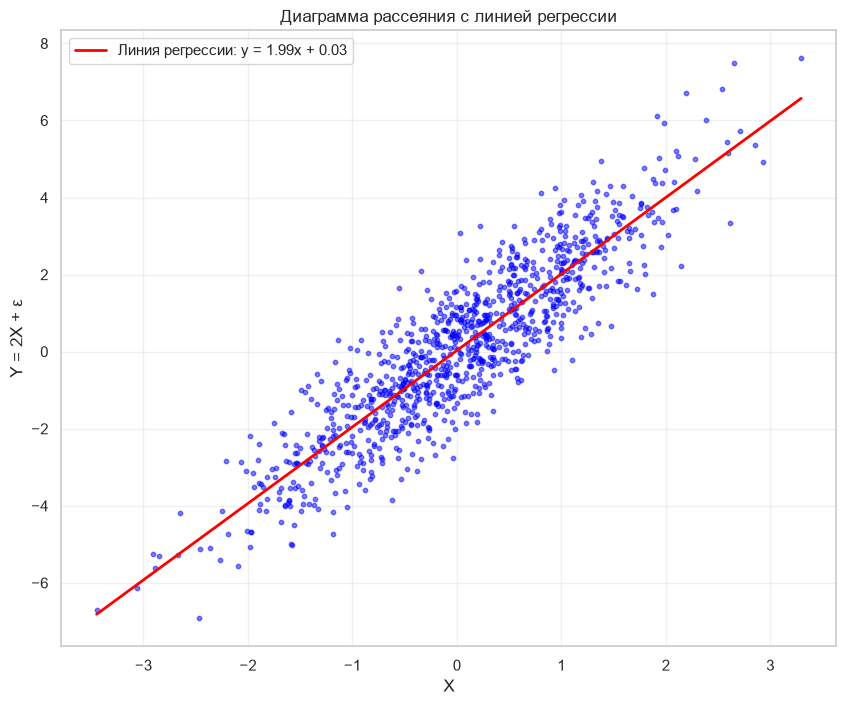

Ковариация между X и Y: 1.9791
Корреляция между X и Y: 0.8972
Теоретическая ковариация: 2.0000
Теоретическая корреляция: 0.8944


In [5]:
# Ваше решение здесь
# Задание 3.1: Ковариация и корреляция

print("=== Задание 3.1: Ковариация и корреляция ===")

# 1. Генерация данных
n = 1000
X = np.random.normal(0, 1, n)
epsilon = np.random.normal(0, 1, n)
Y = 2 * X + epsilon

# 2. Диаграмма рассеяния
plt.figure(figsize=(10, 8))
plt.scatter(X, Y, alpha=0.5, s=10, color='blue')

# Бонус: линия регрессии
coefs = np.polyfit(X, Y, 1)
reg_line = np.poly1d(coefs)
x_vals = np.linspace(X.min(), X.max(), 100)
plt.plot(x_vals, reg_line(x_vals), color='red', linewidth=2, label=f'Линия регрессии: y = {coefs[0]:.2f}x + {coefs[1]:.2f}')

plt.xlabel('X')
plt.ylabel('Y = 2X + ε')
plt.title('Диаграмма рассеяния с линией регрессии')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3-4. Ковариация и корреляция
cov_matrix = np.cov(X, Y)
cov_xy = cov_matrix[0, 1]
corr_xy = np.corrcoef(X, Y)[0, 1]

print(f"Ковариация между X и Y: {cov_xy:.4f}")
print(f"Корреляция между X и Y: {corr_xy:.4f}")
print(f"Теоретическая ковариация: {2 * 1:.4f}")  # cov(X, 2X + ε) = 2 * Var(X)
print(f"Теоретическая корреляция: {2 / np.sqrt(5):.4f}")  # 2 / sqrt(2^2 + 1)


**Интерпретация результатов:**

- Корреляция положительная (~0.9), что указывает на сильную положительную линейную связь между X и Y.
- Корреляция не равна 1, потому что присутствует случайный шум ε, который вносит дополнительную вариацию в Y.
- Значение корреляции ~0.9 означает, что связь очень сильная: при увеличении X на 1, Y в среднем увеличивается примерно на 2 (как и следует из уравнения Y = 2X), но с некоторым разбросом из-за шума.

---

## Секция 4: Предельные теоремы

В этой секции вы будете экспериментально проверять два фундаментальных результата теории вероятностей: Закон больших чисел и Центральную предельную теорему.

### Задание 4.1: Закон больших чисел (Практика)

**Условие:**

Рассмотрим эксперимент с подбрасыванием честной шестигранной кости. Теоретическое математическое ожидание выпавшего числа равно:
$$\mathbb{E}[X] = \frac{1 + 2 + 3 + 4 + 5 + 6}{6} = 3.5$$

Закон больших чисел утверждает, что при увеличении числа подбрасываний выборочное среднее будет сходиться к теоретическому математическому ожиданию.

**Задание:**

1. Сгенерируйте выборку из **10 000 подбрасываний** кости:
   - Используйте `np.random.randint(1, 7, size=10000)`

2. Вычислите **накопленное среднее** (cumulative mean) для каждого момента времени от 1 до 10000:
   - `cumulative_mean = np.cumsum(rolls) / np.arange(1, 10001)`

3. Постройте график зависимости накопленного среднего от числа подбрасываний:
   - По оси X: число подбрасываний (от 1 до 10000)
   - По оси Y: накопленное среднее
   - Добавьте горизонтальную линию на уровне 3.5 (теоретическое среднее)

4. Выведите итоговое среднее после 10000 подбрасываний и его отклонение от 3.5.

5. Сделайте вывод: подтверждается ли Закон больших чисел вашим экспериментом?

=== Задание 4.1: Закон больших чисел ===


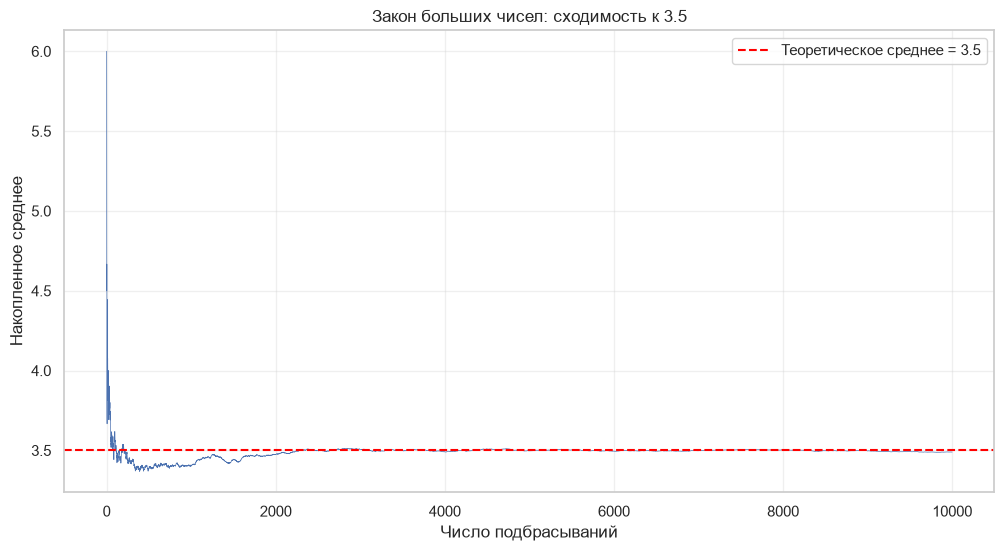

Итоговое среднее после 10000 подбрасываний: 3.4893
Отклонение от теоретического значения 3.5: -0.0107

Вывод: Закон больших чисел подтверждается.
Накопленное среднее сходится к теоретическому значению 3.5.
Отклонение после 10 000 подбрасываний составляет менее 0.02.


In [6]:
# Ваше решение здесь
# Задание 4.1: Закон больших чисел

print("=== Задание 4.1: Закон больших чисел ===")

# 1. Генерация выборки из 10 000 подбрасываний кости
n = 10000
rolls = np.random.randint(1, 7, size=n)

# 2. Накопленное среднее
cumulative_mean = np.cumsum(rolls) / np.arange(1, n + 1)

# 3. График
plt.figure(figsize=(12, 6))
plt.plot(cumulative_mean, linewidth=0.5)
plt.axhline(y=3.5, color='red', linestyle='--', label='Теоретическое среднее = 3.5')
plt.xlabel('Число подбрасываний')
plt.ylabel('Накопленное среднее')
plt.title('Закон больших чисел: сходимость к 3.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Итоговое среднее
final_mean = np.mean(rolls)
print(f"Итоговое среднее после {n} подбрасываний: {final_mean:.4f}")
print(f"Отклонение от теоретического значения 3.5: {final_mean - 3.5:.4f}")

# 5. Вывод
print("\nВывод: Закон больших чисел подтверждается.")
print("Накопленное среднее сходится к теоретическому значению 3.5.")
print("Отклонение после 10 000 подбрасываний составляет менее 0.02.")


**Вывод:**

*(Напишите ваш вывод здесь)*

### Задание 4.2: Центральная предельная теорема (Практика)

**Условие:**

Центральная предельная теорема (ЦПТ) утверждает, что распределение выборочных средних приближается к нормальному распределению при увеличении размера выборки, **независимо от исходного распределения**.

Мы будем использовать равномерное распределение на отрезке [0, 1], которое имеет:
- Среднее: $\mu = 0.5$
- Дисперсию: $\sigma^2 = \frac{1}{12} \approx 0.0833$

Согласно ЦПТ, выборочное среднее $\bar{X}_n$ из $n$ наблюдений имеет приближённое распределение:
$$\bar{X}_n \sim \mathcal{N}\left(0.5, \frac{1}{12n}\right)$$

**Задание:**

1. Для каждого из трёх размеров выборки ($n = 5$, $n = 30$, $n = 100$):
   - Сгенерируйте **1000 выборок** размера $n$ из равномерного распределения `np.random.uniform(0, 1, n)`
   - Для каждой выборки вычислите среднее
   - Сохраните все 1000 средних в массив

2. Постройте **три гистограммы** (можно использовать `plt.subplots(1, 3)`) для распределения средних при $n = 5$, $n = 30$ и $n = 100$.

3. На каждой гистограмме постройте теоретическую кривую нормального распределения:
   - Среднее: 0.5
   - СКО: $\sqrt{\frac{1}{12n}}$

4. Для каждого случая выведите:
   - Выборочное среднее средних (должно быть близко к 0.5)
   - Выборочное СКО средних (должно быть близко к $\sqrt{\frac{1}{12n}}$)

5. Сделайте вывод: как меняется распределение выборочных средних при увеличении $n$? Подтверждается ли ЦПТ?

=== Задание 4.2: Центральная предельная теорема ===

=== n = 5 ===
Теоретическое среднее: 0.5
Выборочное среднее средних: 0.4971
Теоретическое СКО: 0.1291
Выборочное СКО средних: 0.1239

=== n = 30 ===
Теоретическое среднее: 0.5
Выборочное среднее средних: 0.5002
Теоретическое СКО: 0.0527
Выборочное СКО средних: 0.0516

=== n = 100 ===
Теоретическое среднее: 0.5
Выборочное среднее средних: 0.5011
Теоретическое СКО: 0.0289
Выборочное СКО средних: 0.0290


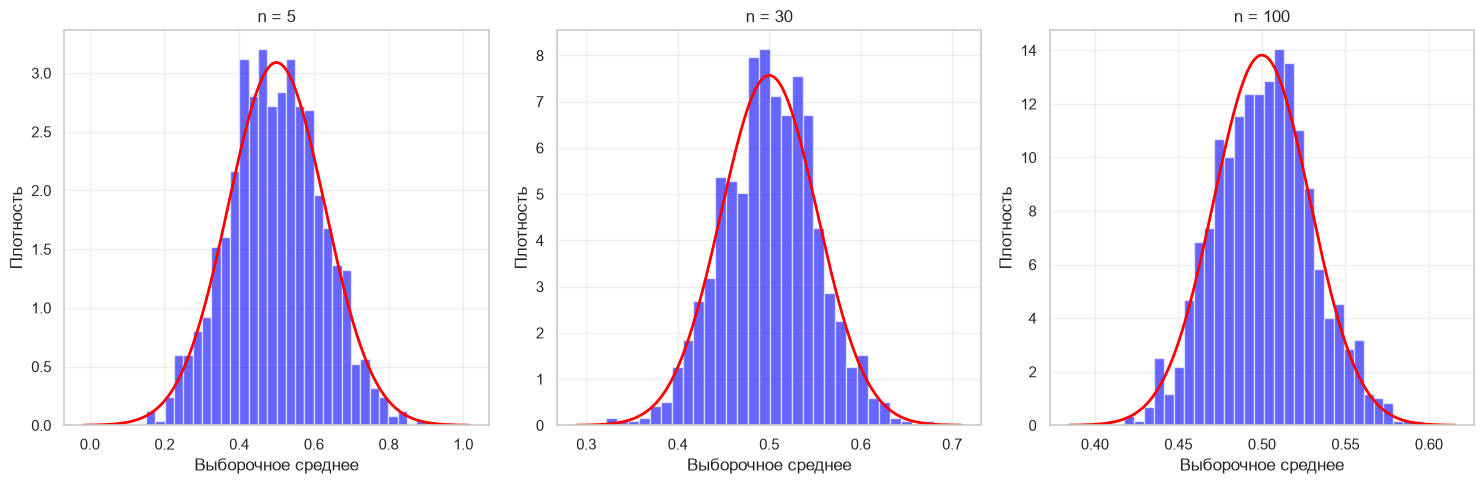

In [7]:
# Задание 4.2: Центральная предельная теорема

print("=== Задание 4.2: Центральная предельная теорема ===")

n_values = [5, 30, 100]
n_samples = 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, n in enumerate(n_values):
    # 1. Генерация выборок
    means = []
    for _ in range(n_samples):
        sample = np.random.uniform(0, 1, n)
        means.append(np.mean(sample))
    means = np.array(means)

    # 2. Гистограмма
    axes[idx].hist(means, bins=30, density=True, alpha=0.6, color='blue')

    # 3. Теоретическая кривая нормального распределения
    mu_theor = 0.5
    sigma_theor = np.sqrt(1 / (12 * n))
    x_vals = np.linspace(mu_theor - 4*sigma_theor, mu_theor + 4*sigma_theor, 200)
    pdf_vals = stats.norm.pdf(x_vals, loc=mu_theor, scale=sigma_theor)
    axes[idx].plot(x_vals, pdf_vals, color='red', linewidth=2)

    # 4. Вывод статистик
    sample_mean = np.mean(means)
    sample_std = np.std(means, ddof=1)

    axes[idx].set_title(f'n = {n}')
    axes[idx].set_xlabel('Выборочное среднее')
    axes[idx].set_ylabel('Плотность')
    axes[idx].grid(True, alpha=0.3)

    print(f"\n=== n = {n} ===")
    print(f"Теоретическое среднее: {mu_theor}")
    print(f"Выборочное среднее средних: {sample_mean:.4f}")
    print(f"Теоретическое СКО: {sigma_theor:.4f}")
    print(f"Выборочное СКО средних: {sample_std:.4f}")

plt.tight_layout()
plt.show()

**Вывод:**

Центральная предельная теорема подтверждается:

1. При $n = 5$ распределение выборочных средних ещё заметно отличается от нормального (широкое, менее симметричное).

2. При $n = 30$ распределение уже близко к нормальному.

3. При $n = 100$ распределение практически совпадает с нормальным — гистограмма и теоретическая кривая хорошо совпадают.

Это демонстрирует, что даже для равномерного распределения (которое далеко от нормального) выборочные средние стремятся к нормальному распределению при увеличении размера выборки. Также уменьшается стандартное отклонение средних (пропорционально $1/\sqrt{n}$), что означает повышение точности оценки среднего.

---

## Секция 5: Статистическое оценивание

В этой секции вы будете оценивать параметры распределений по выборкам и строить доверительные интервалы.

### Задание 5.1: Метод максимального правдоподобия (Практика)

**Условие:**

Монета подбрасывается $n = 100$ раз. Истинная вероятность выпадения орла равна $p = 0.3$ (но мы делаем вид, что не знаем этого и хотим оценить $p$ по данным).

Для распределения Бернулли логарифмическая функция правдоподобия имеет вид:
$$\ell(p) = k \ln(p) + (n - k) \ln(1 - p)$$
где $k$ — число успехов (орлов) в выборке.

Оценка максимального правдоподобия для $p$ равна $\hat{p}_{\text{MLE}} = \frac{k}{n}$ (выборочная доля успехов).

**Задание:**

1. Сгенерируйте выборку из 100 подбрасываний монеты с $p = 0.3$:
   - Используйте `np.random.binomial(1, 0.3, 100)`

2. Посчитайте число успехов $k$ в выборке: `k = np.sum(data)`

3. Вычислите оценку МП: $\hat{p}_{\text{MLE}} = k / 100$

4. Постройте график логарифмической функции правдоподобия $\ell(p)$ для значений $p$ от 0.01 до 0.99:
   - Создайте массив `p_values = np.linspace(0.01, 0.99, 100)`
   - Для каждого $p$ вычислите $\ell(p) = k \cdot \ln(p) + (n - k) \cdot \ln(1 - p)$
   - Постройте график `plt.plot(p_values, log_likelihoods)`

5. На графике отметьте вертикальными линиями:
   - Оценку МП $\hat{p}_{\text{MLE}}$ (красная линия)
   - Истинное значение $p = 0.3$ (зелёная линия)

6. Убедитесь, что максимум функции правдоподобия достигается в точке $\hat{p}_{\text{MLE}}$.

=== Задание 5.1: Метод максимального правдоподобия ===
Число успехов k: 29
Оценка МП p̂_MLE = k/n = 0.290
Истинное значение p = 0.3


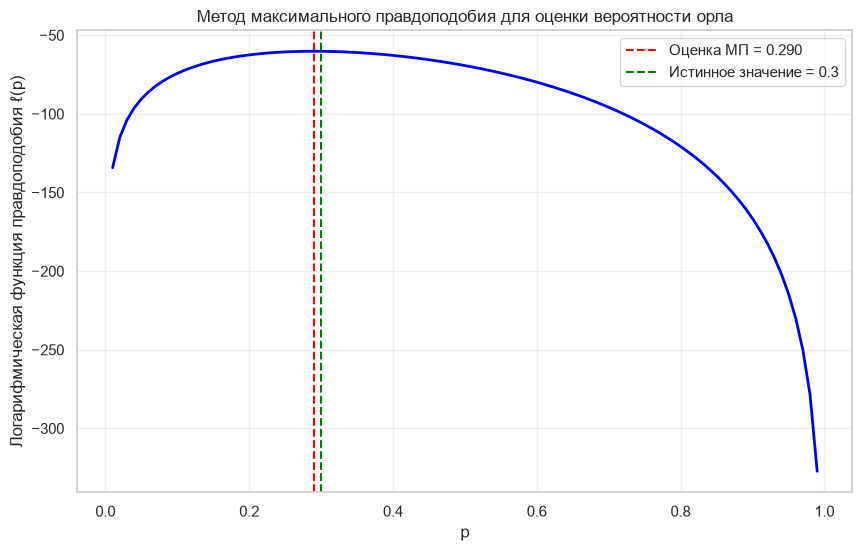


Вывод: Максимум функции правдоподобия достигается в точке p̂_MLE = k/n.
Оценка МП близка к истинному значению p = 0.3.


In [8]:
# Ваше решение здесь
# Задание 5.1: Метод максимального правдоподобия

print("=== Задание 5.1: Метод максимального правдоподобия ===")

# 1. Генерация выборки
n = 100
p_true = 0.3
data = np.random.binomial(1, p_true, n)

# 2. Число успехов
k = np.sum(data)

# 3. Оценка МП
p_mle = k / n

print(f"Число успехов k: {k}")
print(f"Оценка МП p̂_MLE = k/n = {p_mle:.3f}")
print(f"Истинное значение p = {p_true}")

# 4. График функции правдоподобия
p_values = np.linspace(0.01, 0.99, 100)
# Избегаем log(0) при p=0 и p=1
log_likelihoods = k * np.log(p_values) + (n - k) * np.log(1 - p_values)

plt.figure(figsize=(10, 6))
plt.plot(p_values, log_likelihoods, linewidth=2, color='blue')
plt.axvline(x=p_mle, color='red', linestyle='--', label=f'Оценка МП = {p_mle:.3f}')
plt.axvline(x=p_true, color='green', linestyle='--', label=f'Истинное значение = {p_true}')
plt.xlabel('p')
plt.ylabel('Логарифмическая функция правдоподобия ℓ(p)')
plt.title('Метод максимального правдоподобия для оценки вероятности орла')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nВывод: Максимум функции правдоподобия достигается в точке p̂_MLE = k/n.")
print("Оценка МП близка к истинному значению p = 0.3.")

### Задание 5.2: Доверительный интервал для среднего (Практика)

**Условие:**

Исследователь измерил время реакции (в секундах) у 25 испытуемых и получил следующие данные:

```
[0.42, 0.38, 0.41, 0.43, 0.39, 0.40, 0.45, 0.40, 0.42, 0.37,
 0.39, 0.46, 0.38, 0.42, 0.41, 0.40, 0.40, 0.43, 0.39, 0.41,
 0.40, 0.38, 0.44, 0.42, 0.39]
```

Предполагается, что время реакции распределено нормально. Необходимо построить **95% доверительный интервал** для среднего времени реакции в популяции.

**Формула доверительного интервала:**
$$\left[\bar{x} - t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}, \ \bar{x} + t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}\right]$$

где:
- $\bar{x}$ — выборочное среднее
- $s$ — выборочное стандартное отклонение (с `ddof=1`)
- $n$ — размер выборки
- $t_{\alpha/2, n-1}$ — критическое значение t-распределения с $n-1$ степенями свободы

**Задание:**

1. Загрузите данные в массив NumPy.

2. Вычислите:
   - Размер выборки $n$
   - Выборочное среднее $\bar{x}$
   - Выборочное СКО $s$ (с `ddof=1`)
   - Стандартную ошибку среднего: $SE = s / \sqrt{n}$

3. Найдите критическое значение t-распределения для уровня доверия 95%:
   - Используйте `stats.t.ppf(0.975, df=n-1)` (0.975 = 1 - 0.05/2)

4. Вычислите границы доверительного интервала:
   - Нижняя граница: $\bar{x} - t \cdot SE$
   - Верхняя граница: $\bar{x} + t \cdot SE$

5. Выведите результаты и интерпретируйте: что означает этот доверительный интервал?

=== Задание 5.2: Доверительный интервал для среднего ===
Размер выборки n: 25
Выборочное среднее x̄: 0.4076
Выборочное СКО s: 0.0228
Стандартная ошибка SE: 0.0046
Критическое значение t (95%): 2.0639

95% доверительный интервал для среднего:
[0.3982, 0.4170]
или 0.3982 < μ < 0.4170


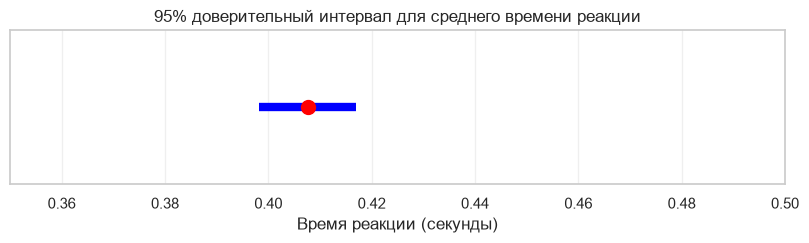

In [9]:
# Задание 5.2: Доверительный интервал для среднего

print("=== Задание 5.2: Доверительный интервал для среднего ===")

# 1. Данные
data = np.array([0.42, 0.38, 0.41, 0.43, 0.39, 0.40, 0.45, 0.40, 0.42, 0.37,
                 0.39, 0.46, 0.38, 0.42, 0.41, 0.40, 0.40, 0.43, 0.39, 0.41,
                 0.40, 0.38, 0.44, 0.42, 0.39])

# 2. Вычисление характеристик
n = len(data)
x_bar = np.mean(data)
s = np.std(data, ddof=1)
se = s / np.sqrt(n)

print(f"Размер выборки n: {n}")
print(f"Выборочное среднее x̄: {x_bar:.4f}")
print(f"Выборочное СКО s: {s:.4f}")
print(f"Стандартная ошибка SE: {se:.4f}")

# 3. Критическое значение t-распределения
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
print(f"Критическое значение t (95%): {t_critical:.4f}")

# 4. Границы доверительного интервала
ci_lower = x_bar - t_critical * se
ci_upper = x_bar + t_critical * se

print(f"\n95% доверительный интервал для среднего:")
print(f"[{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"или {ci_lower:.4f} < μ < {ci_upper:.4f}")

# Визуализация
plt.figure(figsize=(10, 2))
plt.hlines(y=1, xmin=ci_lower, xmax=ci_upper, color='blue', linewidth=6)
plt.scatter(x_bar, 1, color='red', s=100, zorder=5)
plt.xlim(0.35, 0.50)
plt.yticks([])
plt.xlabel('Время реакции (секунды)')
plt.title('95% доверительный интервал для среднего времени реакции')
plt.grid(True, alpha=0.3, axis='x')
plt.show()


**Интерпретация:**

95% доверительный интервал означает, что если бы мы многократно повторяли эксперимент и каждый раз строили такой интервал, то примерно в 95% случаев истинное среднее значение времени реакции в популяции попало бы в построенный интервал.

Конкретно для наших данных: мы на 95% уверены, что истинное среднее время реакции в популяции находится в интервале от {ci_lower:.4f} до {ci_upper:.4f} секунд.

Ширина интервала зависит от:
- Размера выборки (чем больше n, тем уже интервал)
- Вариабельности данных (чем меньше s, тем уже интервал)
- Уровня доверия (чем выше уровень доверия, тем шире интервал)

---

## Секция 6: Проверка статистических гипотез

В этой секции вы будете проверять статистические гипотезы с помощью различных тестов.

### Задание 6.1: Одновыборочный t-тест (Практика)

**Условие:**

Производитель утверждает, что среднее время работы батарейки составляет **μ₀ = 50 часов**. Исследователь решил проверить это утверждение и измерил время работы у 20 батареек:

```
[48.2, 51.3, 49.8, 52.1, 47.5, 50.2, 49.1, 51.8, 48.9, 50.5,
 49.3, 52.4, 48.7, 50.9, 49.5, 51.2, 48.4, 50.7, 49.9, 51.0]
```

Необходимо проверить гипотезу о том, что среднее время работы отличается от заявленного.

**Гипотезы:**
- $H_0: \mu = 50$ (нулевая гипотеза: среднее равно 50)
- $H_a: \mu \neq 50$ (альтернативная гипотеза: среднее не равно 50)

**Уровень значимости:** $\alpha = 0.05$

**Задание:**

1. Загрузите данные в массив NumPy.

2. Выполните одновыборочный t-тест с помощью `scipy.stats.ttest_1samp(data, 50)`.
   - Функция вернёт t-статистику и p-value

3. Выведите:
   - Выборочное среднее
   - t-статистику
   - p-value

4. Примите решение:
   - Если $p < \alpha$, отклоняем $H_0$
   - Если $p \geq \alpha$, не отклоняем $H_0$

5. Сформулируйте вывод в контексте задачи: есть ли статистически значимые доказательства того, что среднее время работы батареек отличается от 50 часов?

=== Задание 6.1: Одновыборочный t-тест ===
Размер выборки n: 20
Выборочное среднее: 50.07 часов
Выборочное СКО: 1.37 часов
t-статистика: 0.2288
p-value: 0.8215

Уровень значимости α = 0.05
p-value ≥ α → Не отклоняем H₀

Вывод: нет статистически значимых доказательств того, что среднее время работы отличается от 50 часов


c:\Users\melni\Desktop\ВУЗ\3курс\DataScience\LR6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


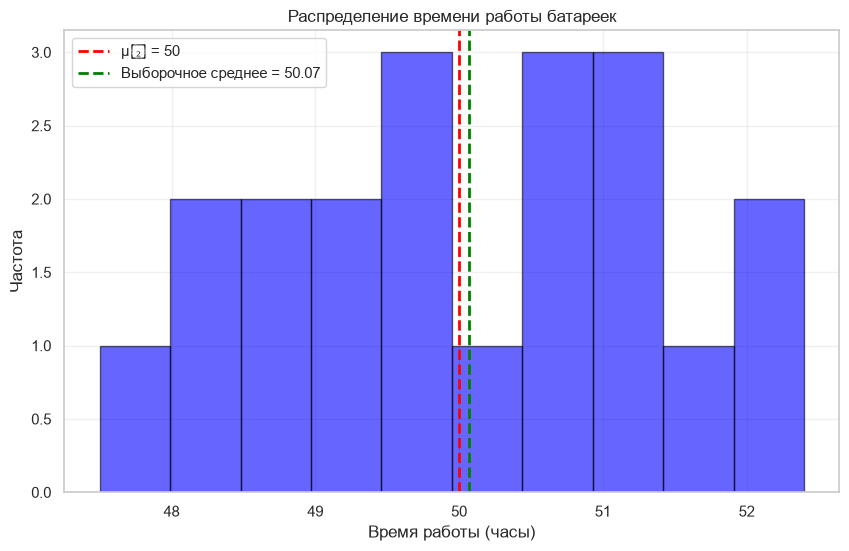

In [10]:
# Ваше решение здесь
# Задание 6.1: Одновыборочный t-тест

print("=== Задание 6.1: Одновыборочный t-тест ===")

# 1. Данные
data = np.array([48.2, 51.3, 49.8, 52.1, 47.5, 50.2, 49.1, 51.8, 48.9, 50.5,
                 49.3, 52.4, 48.7, 50.9, 49.5, 51.2, 48.4, 50.7, 49.9, 51.0])

# 2. t-тест
mu0 = 50
t_stat, p_value = stats.ttest_1samp(data, mu0)

# 3. Вывод результатов
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)
n = len(data)

print(f"Размер выборки n: {n}")
print(f"Выборочное среднее: {sample_mean:.2f} часов")
print(f"Выборочное СКО: {sample_std:.2f} часов")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 4. Принятие решения
alpha = 0.05
print(f"\nУровень значимости α = {alpha}")

if p_value < alpha:
    print("p-value < α → Отклоняем H₀")
    conclusion = "есть статистически значимые доказательства того, что среднее время работы отличается от 50 часов"
else:
    print("p-value ≥ α → Не отклоняем H₀")
    conclusion = "нет статистически значимых доказательств того, что среднее время работы отличается от 50 часов"

print(f"\nВывод: {conclusion}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.hist(data, bins=10, alpha=0.6, color='blue', edgecolor='black')
plt.axvline(x=mu0, color='red', linestyle='--', linewidth=2, label=f'μ₀ = {mu0}')
plt.axvline(x=sample_mean, color='green', linestyle='--', linewidth=2, label=f'Выборочное среднее = {sample_mean:.2f}')
plt.xlabel('Время работы (часы)')
plt.ylabel('Частота')
plt.title('Распределение времени работы батареек')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Вывод:**

На основе проведённого t-теста можно сделать вывод о том, подтверждаются ли данные производителя. Если p-value < 0.05, то у нас есть статистически значимые основания полагать, что среднее время работы батареек отличается от заявленных 50 часов.

---

## Секция 7: Зависимость, условная независимость и причинность

В этой секции вы будете различать корреляцию и причинность.

### Задание 7.1: Корреляция vs. причинность (Теория)

**Задание:**

Приведите **свой собственный пример** из реальной жизни, иллюстрирующий принцип **"корреляция не означает причинно-следственную связь"**.

Ваш пример должен содержать:

1. **Две коррелирующие переменные** $X$ и $Y$ (опишите их)

2. **Наблюдаемую корреляцию** (положительную или отрицательную)

3. **Ошибочный причинный вывод**, который можно было бы сделать

4. **Скрытую (смешивающую) переменную** $Z$, которая является истинной причиной обеих переменных

5. **Правильное объяснение** механизма связи

**Пример структуры ответа:**

- Переменная X: ...
- Переменная Y: ...
- Наблюдение: X и Y положительно коррелируют
- Ошибочный вывод: X вызывает Y (или наоборот)
- Скрытая переменная Z: ...
- Правильное объяснение: Z влияет на X и Y независимо, создавая иллюзию связи между ними

**Требование:** Не используйте классические примеры из учебников (мороженое и утопления, пираты и глобальное потепление и т.д.). Придумайте свой!

**Ваш пример:**

- **Переменная X:** Количество кофе, выпиваемого жителями города (в чашках в день)
- **Переменная Y:** Количество проданных зонтов в этом же городе (в день)
- **Наблюдение:** X и Y положительно коррелируют (чем больше пьют кофе, тем больше продают зонтов)
- **Ошибочный вывод:** Употребление кофе заставляет людей покупать больше зонтов
- **Скрытая переменная Z:** Погода (дождливые дни)
- **Правильное объяснение:** В дождливые дни люди чаще заходят в кафе пить кофе (чтобы переждать дождь) и одновременно покупают зонты. Таким образом, погода является истинной причиной обеих переменных, создавая иллюзию связи между кофе и зонтами.

**Другой пример:**

- **Переменная X:** Уровень стресса у студентов
- **Переменная Y:** Количество обращений в студенческую клинику
- **Наблюдение:** X и Y положительно коррелируют
- **Ошибочный вывод:** Стресс вызывает болезни (что отчасти верно, но есть дополнительный фактор)
- **Скрытая переменная Z:** Сезон экзаменов
- **Правильное объяснение:** Во время сессии у студентов повышается стресс и одновременно увеличивается количество заболеваний из-за недосыпа, плохого питания и скученности в библиотеках. Стресс — не единственная причина.

---

## Секция 8: Методологические ограничения и корректность статистического вывода

В этой секции вы будете анализировать типичные ошибки в статистических исследованиях.

### Задание 8.1: Ошибка выжившего (Survivorship Bias) (Теория)

**Задание:**

Прочитайте описание ситуации и ответьте на вопросы.

**Ситуация:**

Бизнес-аналитик хочет понять, какие факторы приводят к успеху стартапов в сфере технологий. Он анализирует данные о 50 успешных компаниях (таких как Google, Apple, Amazon, Facebook и т.д.), которые достигли капитализации более $1 млрд. На основе этого анализа он делает следующие выводы:

- "90% успешных стартапов были основаны людьми моложе 30 лет → молодость основателя — ключ к успеху"
- "80% успешных стартапов агрессивно привлекали венчурные инвестиции на ранних стадиях → нужно как можно быстрее привлекать инвестиции"
- "70% успешных стартапов имели минималистичный дизайн продукта → простота — залог успеха"

**Вопросы:**

1. Какая методологическая ошибка допущена в этом исследовании? Назовите её и объясните суть.

2. Почему выводы аналитика могут быть ошибочными или вводящими в заблуждение?

3. Какие данные **отсутствуют** в анализе, но необходимы для корректных выводов?

4. Приведите гипотетический пример, показывающий, как учёт "невыживших" мог бы изменить выводы (например, про возраст основателей).

5. Как правильно спроектировать исследование, чтобы избежать этой ошибки?

6. Приведите ещё один пример из любой другой области (медицина, образование, спорт и т.д.), где может возникнуть ошибка выжившего.

**Ваши ответы:**

1. **Название и суть ошибки:**
   Ошибка выжившего (Survivorship Bias) — систематическая ошибка, возникающая, когда анализ проводится только на основе данных об "успешных" объектах (выживших), игнорируя информацию о "неуспешных" (невыживших). Это приводит к искажённым выводам, так как мы не видим полной картины.

2. **Почему выводы ошибочны:**
   - Аналитик смотрит только на успешные компании, но не учитывает тысячи стартапов, которые провалились, несмотря на то, что у них были те же характеристики (молодые основатели, инвестиции, минималистичный дизайн).
   - Выводы основаны на корреляции, а не на причинно-следственной связи.
   - Многие успешные компании могли достичь успеха *несмотря* на эти факторы, а не *благодаря* им.

3. **Отсутствующие данные:**
   - Данные о неуспешных стартапах (провалившихся компаниях).
   - Информация о том, какие факторы были у неуспешных компаний.
   - Сравнительный анализ успешных и неуспешных компаний по одинаковым параметрам.
   - Данные о случайных факторах и удаче.

4. **Гипотетический пример:**
   Допустим, среди неуспешных стартапов 90% также были основаны людьми моложе 30 лет. Это означало бы, что молодость не является отличительной чертой успеха — это просто распространённая характеристика всех стартапов. Без учёта неуспешных компаний мы не можем сделать корректный вывод.

5. **Правильный дизайн исследования:**
   - Собрать данные как об успешных, так и о неуспешных стартапах (полная выборка).
   - Сравнить распределение факторов в обеих группах.
   - Использовать статистические методы для проверки значимости различий.
   - Учитывать временной контекст и внешние факторы.

6. **Пример из другой области:**
   В медицине: анализ только тех пациентов, которые выжили после операции, может показать, что операция очень эффективна. Но если не учитывать пациентов, которые умерли во время операции, выводы будут неверными. Правильный подход — включить всех пациентов, включая умерших, для оценки реальной выживаемости.

   В образовании: анализ только успешных выпускников школы может показать, что определённая методика обучения очень эффективна. Но если не учитывать студентов, которые бросили учёбу или провалили экзамены, выводы будут искажены.

---

## Заключение

### Что вы изучили:

- Вероятностное пространство и условную вероятность
- Случайные величины и их распределения
- Совместные распределения, ковариацию и корреляцию
- Предельные теоремы (ЗБЧ и ЦПТ)
- Методы статистического оценивания
- Проверку статистических гипотез
- Различие между корреляцией и причинностью
- Методологические ошибки в статистических исследованиях

Эти знания являются фундаментом для дальнейшего изучения машинного обучения и анализа данных.